# Plot results for offline prompting in the "farm" example

In [1]:
%cd ..
%pwd  # should be "llm-adaptation"

C:\Users\micha\OneDrive - Univerzita Karlova\research\2024-LLM-DEECo\llm-adaptation


'C:\\Users\\micha\\OneDrive - Univerzita Karlova\\research\\2024-LLM-DEECo\\llm-adaptation'

In [2]:
from pathlib import Path
import pandas as pd
import shutil
import subprocess
import sys
import json
import matplotlib.pyplot as plt
from matplotlib.markers import MarkerStyle
from matplotlib.ticker import FixedFormatter
import numpy as np
import seaborn as sns

In [3]:
results_folder = Path("generated_adaptations/farm")
# results_folder = Path("generated_adaptations/old/251015/farm")
pd.options.display.float_format = "{:,.1f}".format

## Run experiments

In [31]:
prompts = {
    "default": "generated_adaptations/prompts_user/farm_strategy.md",
    # "state": "generated_adaptations/prompts_user/farm_strategy_state.md",
}
variants = {
    "system": "system",
    "constraints": "all",
    # "stats": "stats",
    "result": "result",
}
llms = {
    # "5nanolow": "gpt-5-nano-2025-08-07,reasoning_effort=low",
    "5nano": "gpt-5-nano-2025-08-07",
    # "5mini": "gpt-5-mini-2025-08-07",
    # "5": "gpt-5-2025-08-07",
}
repeats = 2
start = 1

In [32]:
# import generated_adaptations.generator as generator

In [33]:
for prompt_name, prompt in prompts.items():
    for variant, mode in variants.items():
        for llm_name, llm in llms.items():
            for repeat in range(start, start + repeats):
                folder_name = f"{llm_name}_{repeat:02d}"
                print(f"\n{variant}_{prompt_name}/{folder_name}\n")
                folder = results_folder / f"{variant}_{prompt_name}" / folder_name
                folder.mkdir(parents=True, exist_ok=True)
                shutil.copy(prompt, folder / "01_user.md")
                cmd  = [sys.executable, "generated_adaptations/generator.py", f"--folder={str(folder)}", f"--llm={llm}", f"--mode={mode}"]
                result = subprocess.run(cmd, capture_output=True, text=True)  # even capture_output=False does not stream in real-time, so we rather capture it and print it later
                print(result.stdout)
                print(result.stderr)
                # generator.main([f"--folder={str(folder)}"])  # this also does not show the real-time output


system_default/5nano_01

Loaded 2 messages from generated_adaptations\farm\system_default\5nano_01.
Querying LLM with prompt 01_user.
TOKENS USED:
Input: 1024, Output: 6362 (reasoning: 5120)
Response time (seconds): 36.1

LLM response saved to '02_llm.md'.
Code block saved to 'generated_adaptations\farm\system_default\5nano_01\code_02.py'.
Running tests (system): pytest generated_adaptations/tests -q --tb=short -rfExX --show-capture=no --color=no --example=farm --adaptation_name=5nano_01/code_02 --variant=system_default --tests=system
Test exit code: 0
Running tests (functional): pytest generated_adaptations/tests -q --tb=short -rfExX --show-capture=no --color=no --example=farm --adaptation_name=5nano_01/code_02 --variant=system_default --tests=functional
Test exit code: 1
Running tests (all): pytest generated_adaptations/tests -q --tb=short -rfExX --show-capture=no --color=no --example=farm --adaptation_name=5nano_01/code_02 --variant=system_default --tests=all
Test exit code: 1
Runn

## Results

In [34]:
folders = list(results_folder.glob("*/*"))
# folders = list(results_folder.glob("41mini_*"))
# folders = list(results_folder.glob("*/5nanolow*"))
# folders = [results_folder / "41mini"]

folders = [f for f in folders if "mock" not in f.parent.stem]
print([(f.parent.stem, f.stem) for f in folders])

[('constraints_default', '5mini_01'), ('constraints_default', '5mini_02'), ('constraints_default', '5nano_01'), ('constraints_default', '5nano_02'), ('result_default', '5mini_01'), ('result_default', '5mini_02'), ('result_default', '5nano_01'), ('result_default', '5nano_02'), ('system_default', '5mini_01'), ('system_default', '5mini_02'), ('system_default', '5nano_01'), ('system_default', '5nano_02')]


In [35]:
summary = pd.DataFrame(columns=["llm", "params", "repeat"])

for folder in folders:
    llm, repeat = folder.stem.split("_")
    params = folder.parent.stem
    summary.loc[len(summary), ["llm", "params", "repeat"]] = [llm, params, repeat]

    for file in (folder / "results").glob("*.txt"):
        name = file.stem.removeprefix("code_")
        code = name.split("_")[0]
        if "_missing" in name:
            summary.loc[len(summary) - 1, code + "_system"] = "missing"
        elif "_system_fail" in name:
            summary.loc[len(summary) - 1, code + "_system"] = "fail"
        elif "_system_pass" in name:
            summary.loc[len(summary) - 1, code + "_system"] = "pass"
        elif "_all_fail" in name:
            summary.loc[len(summary) - 1, code + "_all"] = "fail"
        elif "_all_pass" in name:
            summary.loc[len(summary) - 1, code + "_all"] = "pass"
        elif "_functional_fail" in name:
            summary.loc[len(summary) - 1, code + "_functional"] = "fail"
        elif "_functional_pass" in name:
            summary.loc[len(summary) - 1, code + "_functional"] = "pass"
        else:
            print(f"Unknown file: {file}")
    for file in (folder / "results").glob("*.json"):
        name = file.stem.removeprefix("code_")
        if "_simulation_result" in name:
            code = name.removesuffix("_simulation_result")
            results = json.load(open(file))
            result = results["damage"]
            summary.loc[len(summary) - 1, code + "_result"] = result
        else:
            print(f"Unknown file: {file}")
summary.fillna("", inplace=True)

C:\Users\micha\AppData\Local\Temp\ipykernel_19408\473530000.py:36: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  summary.fillna("", inplace=True)


In [36]:
summary.set_index(["llm", "params", "repeat"], inplace=True)

In [37]:
summary = summary.reindex(sorted(summary.columns), axis=1)

In [38]:
summary

02_all 02_functional  02_result 02_system  \
llm   params              repeat                                             
5mini constraints_default 01       fail          fail      129.7      pass   
                          02       fail          fail      127.0      pass   
5nano constraints_default 01       fail          fail      119.7      fail   
                          02       fail          fail      137.3      fail   
5mini result_default      01       fail          fail      127.0      pass   
                          02       fail          fail      127.0      pass   
5nano result_default      01       fail          fail      129.7      fail   
                          02       fail          fail      129.7      pass   
5mini system_default      01       fail          fail      119.7      pass   
                          02       fail          fail      123.0      pass   
5nano system_default      01       fail          fail      127.0      pass   
                          02       fail          fail      127.0      pass   

                                 04_all 04_functional  04_result 04_system  \
llm   params              repeat                                             
5mini constraints_default 01       pass          pass      118.3      pass   
                          02       fail          fail      202.0      pass   
5nano constraints_default 01       pass          pass      146.0      pass   
                          02       fail          fail      129.7      pass   
5mini result_default      01       pass          pass       48.0      pass   
                          02       pass          pass       57.0      pass   
5nano result_default      01       fail          fail      311.7      pass   
                          02       fail          fail      166.3      pass   
5mini system_default      01       fail          fail      181.7      pass   
                          02       fail          fail       55.7      pass   
5nano system_default      01       fail          pass      127.7      fail   
                          02       fail          fail      225.7      pass   

                                 06_all 06_functional  ... 16_result  \
llm   params              repeat                       ...             
5mini constraints_default 01       fail          fail  ...     162.3   
                          02       pass          pass  ...             
5nano constraints_default 01       fail          fail  ...      89.3   
                          02       fail          fail  ...      57.7   
5mini result_default      01                           ...             
                          02                           ...             
5nano result_default      01       fail          fail  ...     269.0   
                          02       fail          fail  ...             
5mini system_default      01                           ...             
                          02                           ...     302.0   
5nano system_default      01       pass          pass  ...             
                          02       fail          fail  ...             

                                 16_system 18_all 18_functional 18_result  \
llm   params              repeat                                            
5mini constraints_default 01          pass   pass          pass     138.0   
                          02                                                
5nano constraints_default 01          pass   fail          fail      50.7   
                          02          pass   fail          fail     129.7   
5mini result_default      01                                                
                          02                                                
5nano result_default      01          pass   fail          fail     234.7   
                          02                                                
5mini system_default      01       missing                          

### Plot

In [39]:
colors = {
    "5nano/constraints": "tab:blue",
    "5nano/system": "tab:green",
    "5nano/result": "tab:orange",
    "5nano/stats": "tab:red",
}
colors = {
    "5nano/constraints_state": "tab:blue",
    "5nano/constraints_default": "tab:cyan",
    "5nano/system_state": "tab:green",
    "5nano/system_default": "tab:olive",
    "5nano/result_state": "tab:orange",
    "5nano/result_default": "tab:brown",
    "5nano/stats_state": "tab:red",
    "5nano/stats_default": "tab:pink",
}
colors = {
    "5nano/constraints_default": "tab:blue",
    "5mini/constraints_default": "tab:cyan",
    "5nano/system_default": "tab:green",
    "5mini/system_default": "tab:olive",
    "5nano/result_default": "tab:orange",
    "5mini/result_default": "tab:brown",
    # "5nano/stats_default": "tab:red",
    # "5mini/stats_default": "tab:pink",
}

In [40]:
result_cols = [col for col in summary.columns if col.endswith("_result")]
plot_data = summary[result_cols].replace({"": np.nan}).astype(float)
plot_data

C:\Users\micha\AppData\Local\Temp\ipykernel_19408\65529393.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  plot_data = summary[result_cols].replace({"": np.nan}).astype(float)


02_result  04_result  06_result  08_result  \
llm   params              repeat                                               
5mini constraints_default 01          129.7      118.3      272.3        NaN   
                          02          127.0      202.0      114.3      138.0   
5nano constraints_default 01          119.7      146.0       62.3      146.0   
                          02          137.3      129.7      111.7      129.7   
5mini result_default      01          127.0       48.0        NaN        NaN   
                          02          127.0       57.0        NaN        NaN   
5nano result_default      01          129.7      311.7      163.0      179.0   
                          02          129.7      166.3      110.0      192.0   
5mini system_default      01          119.7      181.7        NaN      144.0   
                          02          123.0       55.7        NaN       54.3   
5nano system_default      01          127.0      127.7       50.7        NaN   
                          02          127.0      225.7      299.7      321.3   

                                  10_result  12_result  14_result  16_result  \
llm   params              repeat                                               
5mini constraints_default 01          108.0      138.3        NaN      162.3   
                          02           56.7        NaN        NaN        NaN   
5nano constraints_default 01          312.0      295.0      302.7       89.3   
                          02          103.3      129.7      135.3       57.7   
5mini result_default      01            NaN        NaN        NaN        NaN   
                          02            NaN        NaN        NaN        NaN   
5nano result_default      01          179.0      234.7       44.7      269.0   
                          02          170.7      192.0       46.7        NaN   
5mini system_default      01            NaN        NaN        NaN        NaN   
                          02            NaN       62.7      108.3      302.0   
5nano system_default      01            NaN        NaN        NaN        NaN   
                          02          167.7       50.7        NaN        NaN   

                                  18_result  20_result  
llm   params              repeat                        
5mini constraints_default 01          138.0        NaN  
                          02            NaN        NaN  
5nano constraints_default 01           50.7       60.3  
                          02          129.7      172.0  
5mini result_default      01            NaN        NaN  
                          02            NaN        NaN  
5nano result_default      01          234.7      319.3  
                          02            NaN        NaN  
5mini system_default      01            NaN      105.0  
                          02            NaN       40.7  
5nano system_default      01            NaN        NaN  
                          02            NaN        NaN

In [41]:
stop_by_constraints = plot_data.copy()

def clear_after_pass(row):
    passed = False

    for col in row.index:
        if not passed:
            constraints_col = col.replace('_result', '_all')
            if summary.loc[row.name, constraints_col] == "pass":
                passed = True
        else:
            row[col] = np.nan
    return row

stop_by_constraints = stop_by_constraints.apply(clear_after_pass, axis=1)
plot_data = stop_by_constraints
stop_by_constraints

02_result  04_result  06_result  08_result  \
llm   params              repeat                                               
5mini constraints_default 01          129.7      118.3        NaN        NaN   
                          02          127.0      202.0      114.3        NaN   
5nano constraints_default 01          119.7      146.0        NaN        NaN   
                          02          137.3      129.7      111.7      129.7   
5mini result_default      01          127.0       48.0        NaN        NaN   
                          02          127.0       57.0        NaN        NaN   
5nano result_default      01          129.7      311.7      163.0      179.0   
                          02          129.7      166.3      110.0      192.0   
5mini system_default      01          119.7      181.7        NaN      144.0   
                          02          123.0       55.7        NaN       54.3   
5nano system_default      01          127.0      127.7       50.7        NaN   
                          02          127.0      225.7      299.7      321.3   

                                  10_result  12_result  14_result  16_result  \
llm   params              repeat                                               
5mini constraints_default 01            NaN        NaN        NaN        NaN   
                          02            NaN        NaN        NaN        NaN   
5nano constraints_default 01            NaN        NaN        NaN        NaN   
                          02          103.3      129.7      135.3       57.7   
5mini result_default      01            NaN        NaN        NaN        NaN   
                          02            NaN        NaN        NaN        NaN   
5nano result_default      01          179.0      234.7       44.7      269.0   
                          02          170.7      192.0       46.7        NaN   
5mini system_default      01            NaN        NaN        NaN        NaN   
                          02            NaN       62.7        NaN        NaN   
5nano system_default      01            NaN        NaN        NaN        NaN   
                          02          167.7        NaN        NaN        NaN   

                                  18_result  20_result  
llm   params              repeat                        
5mini constraints_default 01            NaN        NaN  
                          02            NaN        NaN  
5nano constraints_default 01            NaN        NaN  
                          02          129.7      172.0  
5mini result_default      01            NaN        NaN  
                          02            NaN        NaN  
5nano result_default      01          234.7      319.3  
                          02            NaN        NaN  
5mini system_default      01            NaN      105.0  
                          02            NaN        NaN  
5nano system_default      01            NaN        NaN  
                          02            NaN        NaN

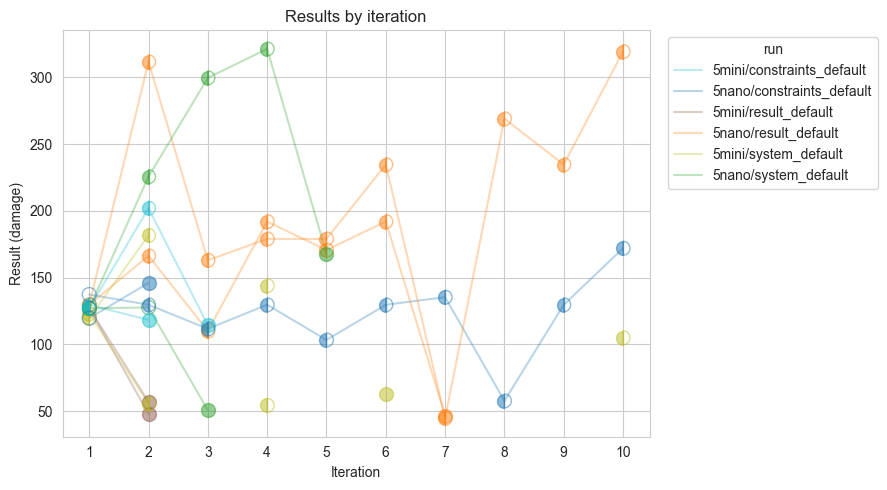

In [42]:
plot_df = plot_data.T.copy()  # index: result columns like `02_result`, columns: MultiIndex (llm, params, repeat)
orig_cols = plot_df.columns  # MultiIndex
labels = [f"{llm}/{params}/{repeat}" for llm, params, repeat in orig_cols]
x = list(range(1, len(plot_df.index) + 1))

fig, ax = plt.subplots(figsize=(9, 5))
for col, label in zip(orig_cols, labels):
    y = plot_df[col].values
    # draw the line for the run
    label_no_repeat = label.rsplit("/", 1)[0]
    # color = colors[label.rsplit("/", 1)[0].rsplit("_", 1)[0]]
    if label_no_repeat not in colors:
        continue

    color = colors[label_no_repeat]
    if label_no_repeat in ax.get_legend_handles_labels()[1]:
        label_no_repeat = None
    line, = ax.plot(x, y, '-', label=label_no_repeat, alpha=0.3, color=color)

    # collect indices by test status
    pass_idx, half_idx, fail_idx = [], [], []
    for i, result_col in enumerate(plot_df.index):  # e.g. '02_result'
        system_col = result_col.replace('_result', '_system')
        functional_col = result_col.replace('_result', '_functional')
        all_col = result_col.replace('_result', '_all')

        system = summary.loc[col, system_col]
        functional = summary.loc[col, functional_col] if functional_col in summary.columns else summary.loc[col, all_col]

        if system == "pass" and functional == "pass":
            pass_idx.append(i)
        elif system == "pass":
            half_idx.append(i)
        else:
            fail_idx.append(i)

    # overplot markers (use same color as the line)
    scatter_kwargs = {
        "zorder": 5 if "constraints" in label else 3,
        "s": 100, "alpha": 0.5
    }
    if pass_idx:
        ax.scatter([x[i] for i in pass_idx], [y[i] for i in pass_idx], marker='o', color=color, **scatter_kwargs)
    if half_idx:
        ax.scatter([x[i] for i in half_idx], [y[i] for i in half_idx], marker=MarkerStyle("o", fillstyle="left"), color=color, **scatter_kwargs)
        ax.scatter([x[i] for i in half_idx], [y[i] for i in half_idx], marker=MarkerStyle("o", fillstyle="right"), color="none", edgecolors=color, **scatter_kwargs)
    if fail_idx:
        ax.scatter([x[i] for i in fail_idx], [y[i] for i in fail_idx], marker='o', color=color, facecolors='none', **scatter_kwargs)

# finalize axes
ax.set_xticks(x)
ax.set_xticklabels(x)  # iterations 1,2,3,...
ax.set_xlabel("Iteration")
ax.set_ylabel("Result (damage)")
ax.set_title("Results by iteration")
ax.legend(title="run", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Iterations counts

In [43]:
iterations = plot_data.apply(lambda row: row.count(), axis=1)
iterations = pd.DataFrame(iterations).rename(columns={0: "iterations"})
iterations

iterations
llm   params              repeat            
5mini constraints_default 01               2
                          02               3
5nano constraints_default 01               2
                          02              10
5mini result_default      01               2
                          02               2
5nano result_default      01              10
                          02               7
5mini system_default      01               4
                          02               4
5nano system_default      01               3
                          02               5

<Axes: xlabel='iterations', ylabel='params'>

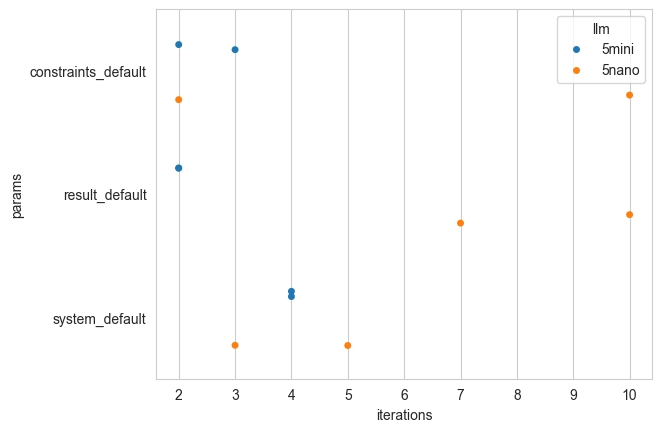

In [44]:
sns.stripplot(x="iterations", y="params", hue="llm", data=iterations.reset_index(), dodge=True)